In [1]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

In [2]:
from src.data_loader import load_data

In [3]:
market = '^GSPC'

tickers = [
    "AAPL","MSFT","GOOGL","NVDA","NFLX",
    "JPM","BAC","GS",
    "JNJ","PFE","UNH",
    "KO","PG","AMZN","HD",
    "BA","CAT",
    "XOM","CVX",
    "DIS"
    ]

In [4]:
r_m, returns = load_data(market, tickers, filepath=project_root / "data/stock_data_20.csv", end='2021-01-01')
stocks = returns.columns

In [5]:
from src.trajectory_generation import bootstrap_samples, stationary_bootstrap

## Bootstrap CAPM

In [6]:
(np.exp(r_m.sum()) -1) / 10

np.float64(0.22939744139226498)

In [7]:
r_m_adj = r_m - r_m.mean() + 0.0002

In [8]:
(np.exp(r_m_adj.sum()) -1) / 10

np.float64(0.07391561076942095)

### With alpha

In [149]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

capm = {}
capm_res = pd.DataFrame()
coeffs = pd.DataFrame()

for stock in stocks:
    lm = linear_model.OLS(returns[stock], sm.add_constant(r_m.rename('market'))).fit()
    capm[stock], capm_res[stock] = lm, lm.resid
    coeffs.loc[:, stock] = lm.params
    print(f"{stock}: alpha={lm.params['const']:.4f}, beta={lm.params['market']:.4f}, p_alpha={lm.pvalues['const']:.4f}, p_beta={lm.pvalues['market']:.4f}")

AAPL: alpha=0.0006, beta=1.0663, p_alpha=0.0138, p_beta=0.0000
MSFT: alpha=0.0003, beta=1.0851, p_alpha=0.0968, p_beta=0.0000
GOOGL: alpha=0.0002, beta=1.0160, p_alpha=0.4206, p_beta=0.0000
NVDA: alpha=0.0006, beta=1.4576, p_alpha=0.1282, p_beta=0.0000
NFLX: alpha=0.0011, beta=0.9975, p_alpha=0.0577, p_beta=0.0000
JPM: alpha=-0.0001, beta=1.2927, p_alpha=0.7485, p_beta=0.0000
BAC: alpha=-0.0004, beta=1.5054, p_alpha=0.2038, p_beta=0.0000
GS: alpha=-0.0003, beta=1.2647, p_alpha=0.1441, p_beta=0.0000
JNJ: alpha=0.0002, beta=0.6444, p_alpha=0.2955, p_beta=0.0000
PFE: alpha=0.0001, beta=0.7484, p_alpha=0.6566, p_beta=0.0000
UNH: alpha=0.0005, beta=0.9807, p_alpha=0.0336, p_beta=0.0000
KO: alpha=0.0001, beta=0.6492, p_alpha=0.6303, p_beta=0.0000
PG: alpha=0.0002, beta=0.5824, p_alpha=0.3165, p_beta=0.0000
AMZN: alpha=0.0007, beta=1.0081, p_alpha=0.0216, p_beta=0.0000
HD: alpha=0.0005, beta=0.9745, p_alpha=0.0107, p_beta=0.0000
BA: alpha=-0.0000, beta=1.3477, p_alpha=0.9933, p_beta=0.0000
CA

In [378]:
(np.exp(coeffs.loc['const'] * 252) - 1)

AAPL     0.171556
MSFT     0.087916
GOOGL    0.046578
NVDA     0.166838
NFLX     0.319001
JPM     -0.017273
BAC     -0.088190
GS      -0.082069
JNJ      0.040951
PFE      0.021347
UNH      0.134981
KO       0.019711
PG       0.042567
AMZN     0.199624
HD       0.128057
BA      -0.000667
CAT     -0.002142
XOM     -0.109324
CVX     -0.074230
DIS      0.063309
Name: const, dtype: float64

In [303]:
import src.trajectory_generation
from importlib import reload
reload(src.trajectory_generation)
from src.trajectory_generation import simulate_capm

In [389]:
sims = []
for i in range(1000):
    simulated_returns, _ = simulate_capm(coeffs.loc['const']*.5, coeffs.loc['market'], capm_res, r_m, 1, 252, desired_market_return = 0.000228, wild=True)

    sims.append(simulated_returns)
sims = np.array(sims)

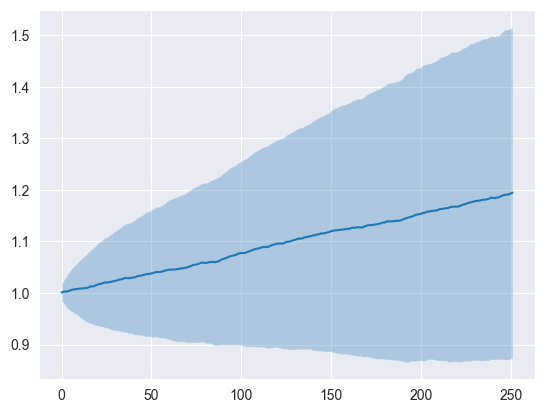

In [390]:
dd = np.exp(sims[:, :, 0])
dd = pd.DataFrame(dd)
dd = dd.T.cumprod()

import matplotlib.pyplot as plt

plt.plot(dd.mean(axis=1))
plt.fill_between(dd.index, dd.mean(axis=1) - dd.std(axis=1), dd.mean(axis=1) + dd.std(axis=1), alpha=0.3)
plt.show()

### Without alpha

In [9]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

capm = {}
capm_res = pd.DataFrame()
coeffs = pd.DataFrame()

for stock in stocks:
    lm = linear_model.OLS(returns[stock], r_m_adj.rename('market')).fit()
    capm[stock], capm_res[stock] = lm, lm.resid
    coeffs.loc[:, stock] = lm.params

In [620]:
coeffs

,AAPL,MSFT,GOOGL,NVDA,NFLX,JPM,BAC,GS,JNJ,PFE,UNH,KO,PG,AMZN,HD,BA,CAT,XOM,CVX,DIS
market,1.067747,1.086077,1.01671,1.459113,0.999652,1.293037,1.505368,1.264581,0.644887,0.748788,0.981917,0.649525,0.582882,1.009709,0.975694,1.348203,1.217346,0.975304,1.133351,1.003695


In [621]:
def simulate_capm(alphas, betas, capm_res, market, n_simulations, n_samples, shrink_betas=1.0, wild=False, block_size=20):
    
    if n_simulations > 1:
        raise NotImplementedError("Only n_simulations=1 is currently supported.")

    market_returns = bootstrap_samples(market, n_simulations, n_samples, block_size=block_size)
    
    if alphas is None:
        alphas = np.zeros(betas.shape[0])
        betas =  betas.to_numpy() * shrink_betas
    else:
        alphas, betas = alphas.to_numpy(), betas.to_numpy() * shrink_betas

    resids = bootstrap_samples(capm_res, n_simulations, n_samples, block_size=block_size)
    
    if wild:
        signs = np.random.choice([-1, 1], size=(resids[0].shape[0], 1)) # same across t
        resids = resids * signs

    simulations = alphas[None, :] + market_returns.T @ betas[None, :] + resids[0]

    return simulations, market_returns

In [779]:
# reload trajectory generation .py
import src.trajectory_generation
from importlib import reload
reload(src.trajectory_generation)
from src.trajectory_generation import simulate_capm

In [778]:
from joblib import load, dump

dd = {'betas': coeffs.T['market'], 'capm_res':capm_res, 'r_m_adj':r_m_adj}
dump(dd, project_root / 'results/capm_boot_prereqs.joblib')

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\capm_boot_prereqs.joblib']

In [780]:
trajectories, m_sim = simulate_capm(None, coeffs.T['market'], capm_res, r_m_adj, 1, 2767, wild=True, shrink_betas=0.9, block_size=30)

In [772]:
cums = np.zeros((1000))

for i in range(1000):
    trajectories, m_sim = simulate_capm(None, coeffs.T['market'], capm_res, r_m_adj, 1, 2767, wild=True, shrink_betas=0.9, block_size=30)
    cums[i] = (np.exp(m_sim.sum()) - 1) / 10
cums = pd.Series(cums)

In [776]:
cums.describe()

count    1000.000000
mean        0.099335
std         0.100415
min        -0.060970
25%         0.026822
50%         0.078940
75%         0.148527
max         0.627607
dtype: float64

<Axes: >

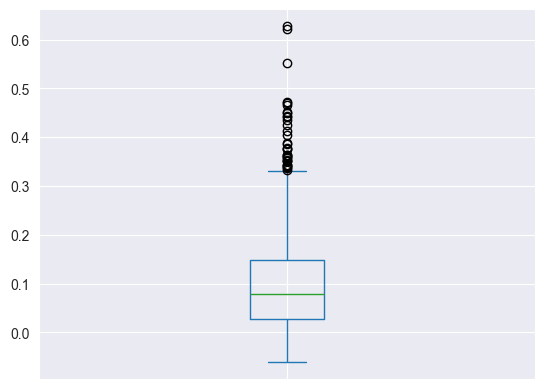

In [774]:
cums.plot(kind='box')

In [775]:
cums

0      0.003179
1      0.294974
2      0.050974
3      0.364194
4      0.035183
         ...   
995    0.444020
996    0.088132
997    0.203703
998    0.061165
999    0.102979
Length: 1000, dtype: float64

<Axes: >

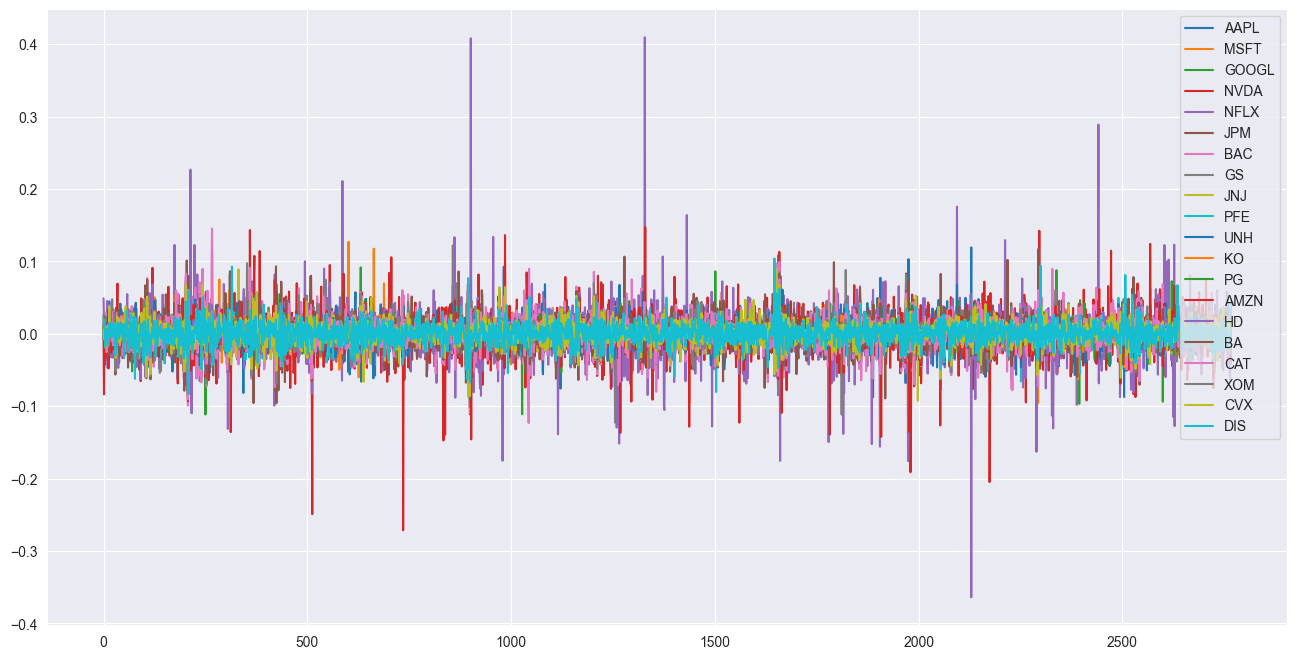

In [752]:
traj_df = pd.DataFrame(trajectories, columns = stocks)
traj_df.plot(figsize=(16,8))

In [753]:
traj_df.describe()

,AAPL,MSFT,GOOGL,NVDA,NFLX,JPM,BAC,GS,JNJ,PFE,UNH,KO,PG,AMZN,HD,BA,CAT,XOM,CVX,DIS
count,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2.767000e+03,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000
mean,-0.000328,-0.000165,0.000229,-0.000385,-0.000459,0.000486,0.000203,0.000440,0.000250,0.000210,6.559503e-07,-0.000034,-0.000020,-0.000004,0.000041,0.000270,0.000381,0.000286,0.000273,0.000276
std,0.017801,0.015019,0.015498,0.026363,0.032779,0.017453,0.021462,0.017979,0.010209,0.011848,1.595759e-02,0.010063,0.009824,0.019737,0.013625,0.019654,0.017234,0.013582,0.015302,0.014230
min,-0.087753,-0.095742,-0.111587,-0.271473,-0.364048,-0.101334,-0.123475,-0.122942,-0.092594,-0.080539,-8.485439e-02,-0.062678,-0.051952,-0.145954,-0.075216,-0.096036,-0.090889,-0.074561,-0.087234,-0.083478
25%,-0.009605,-0.008254,-0.007913,-0.014294,-0.014916,-0.009003,-0.011675,-0.009336,-0.005122,-0.006422,-8.882399e-03,-0.005615,-0.005299,-0.009219,-0.007802,-0.010211,-0.009238,-0.007068,-0.008227,-0.007129
50%,0.000013,0.000309,0.001038,0.000741,0.000108,0.000438,0.000605,0.000917,0.000478,0.000208,4.025250e-04,0.000231,0.000078,0.000578,0.000376,0.000690,0.000987,0.000418,0.000350,0.000637
75%,0.009767,0.008152,0.008724,0.014159,0.015021,0.010402,0.012348,0.010765,0.005868,0.007136,9.434582e-03,0.005786,0.005370,0.010014,0.007766,0.011058,0.010473,0.007963,0.009100,0.008264
max,0.119262,0.126876,0.108383,0.143150,0.409474,0.106506,0.145329,0.122210,0.088956,0.059554,6.837064e-02,0.054099,0.058382,0.147115,0.072268,0.117448,0.090996,0.060946,0.090228,0.103899


In [692]:
returns.describe()

,AAPL,MSFT,GOOGL,NVDA,NFLX,JPM,BAC,GS,JNJ,PFE,UNH,KO,PG,AMZN,HD,BA,CAT,XOM,CVX,DIS
count,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000,2767.000000
mean,0.001088,0.000802,0.000618,0.001240,0.001528,0.000488,0.000282,0.000205,0.000437,0.000406,0.000925,0.000357,0.000416,0.001157,0.000898,0.000578,0.000516,-0.000039,0.000182,0.000676
std,0.017850,0.016000,0.016288,0.026593,0.032348,0.018245,0.022513,0.018579,0.010715,0.012912,0.016494,0.011095,0.010807,0.019929,0.014592,0.022382,0.018461,0.015010,0.017271,0.015664
min,-0.137708,-0.159453,-0.123685,-0.207712,-0.429178,-0.162106,-0.227129,-0.136863,-0.105781,-0.080501,-0.189671,-0.101728,-0.091428,-0.135325,-0.220570,-0.272444,-0.154109,-0.130391,-0.250062,-0.139085
25%,-0.006969,-0.006845,-0.006642,-0.011315,-0.012649,-0.007659,-0.010096,-0.008475,-0.004192,-0.005911,-0.006920,-0.004531,-0.004404,-0.008340,-0.005405,-0.008421,-0.008122,-0.006626,-0.007145,-0.006201
50%,0.000969,0.000684,0.000682,0.001446,0.000391,0.000461,0.000575,0.000566,0.000399,0.000000,0.000982,0.000482,0.000479,0.001071,0.000940,0.000857,0.000471,-0.000115,0.000426,0.000694
75%,0.010359,0.008637,0.008779,0.014113,0.016304,0.008979,0.010974,0.009581,0.005697,0.006816,0.008731,0.005716,0.005517,0.011588,0.007769,0.009779,0.010116,0.006968,0.007638,0.007885
max,0.113158,0.132929,0.150645,0.260876,0.352230,0.165621,0.163785,0.161951,0.076940,0.085817,0.120437,0.062783,0.113409,0.146225,0.128840,0.217677,0.098324,0.119442,0.204904,0.134639


In [754]:
cum_returns = (np.exp(traj_df.sum()) -1) / 10
cum_returns

AAPL    -0.059595
MSFT    -0.036636
GOOGL    0.088654
NVDA    -0.065491
NFLX    -0.071886
JPM      0.283411
BAC      0.075417
GS       0.238330
JNJ      0.099664
PFE      0.078745
UNH      0.000182
KO      -0.008999
PG      -0.005476
AMZN    -0.001021
HD       0.012119
BA       0.110946
CAT      0.187355
XOM      0.120942
CVX      0.112651
DIS      0.114388
dtype: float64

In [755]:
cum_market_return = (np.exp(m_sim.sum()) -1) / 10
cum_market_return

np.float64(0.039950820047510674)

In [756]:
current = traj_df.cumsum()
peak = current.cummax()
draw_down = (peak - current) / peak

draw_down_df = pd.DataFrame({'mean_drawdown': draw_down.mean(), 'max_drawdown': draw_down.max()})
draw_down_df

,mean_drawdown,max_drawdown
AAPL,1.176225,4.609220
MSFT,1.780196,3.434787
GOOGL,1.835221,39.716354
NVDA,2.383160,5.829328
NFLX,1.125116,7.184065
JPM,0.968942,3.223313
BAC,0.960920,2.558753
GS,0.616407,3.022171
JNJ,1.640173,17.787603
PFE,1.490923,5.130089


In [757]:
sharpe_ratios = traj_df.mean() / traj_df.std() * np.sqrt(252)
sharpe_ratios

AAPL    -0.292060
MSFT    -0.174288
GOOGL    0.234978
NVDA    -0.231540
NFLX    -0.222090
JPM      0.441773
BAC      0.150232
GS       0.388945
JNJ      0.388574
PFE      0.281232
UNH      0.000653
KO      -0.053761
PG      -0.032890
AMZN    -0.002984
HD       0.048170
BA       0.217886
CAT      0.351379
XOM      0.334839
CVX      0.282882
DIS      0.307457
dtype: float64

In [758]:
np.linalg.eigvals(traj_df.cov()).max() / np.linalg.eigvals(traj_df.cov()).sum()

np.float64(0.41928249691665714)

<Axes: >

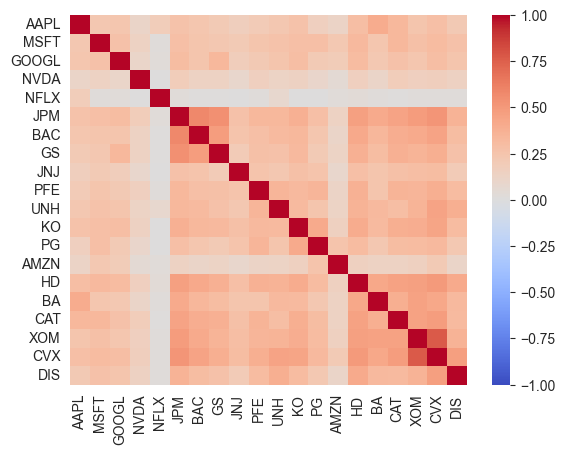

In [759]:
sns.heatmap((traj_df**2).corr(), vmin=-1, vmax=1, cmap='coolwarm')

In [760]:
linear_traj = np.exp(traj_df) - 1
lin_r = np.exp(returns) - 1

def stress_idx(linear_traj):

    eq_weight_r = linear_traj.mean(axis=1)

    stress_idx = eq_weight_r[eq_weight_r < eq_weight_r.quantile(0.01)].index
    return stress_idx

<Axes: >

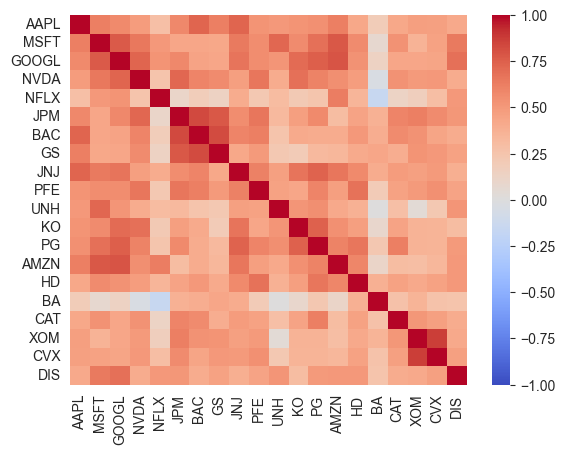

In [761]:
sns.heatmap(linear_traj.loc[stress_idx(linear_traj)].corr(), vmin=-1, vmax=1, cmap='coolwarm')

<Axes: >

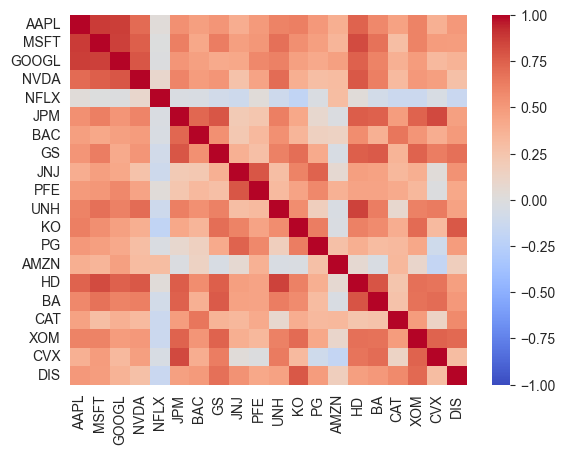

In [762]:
sns.heatmap(returns.loc[stress_idx(returns)].corr(), vmin=-1, vmax=1, cmap='coolwarm')

<Axes: >

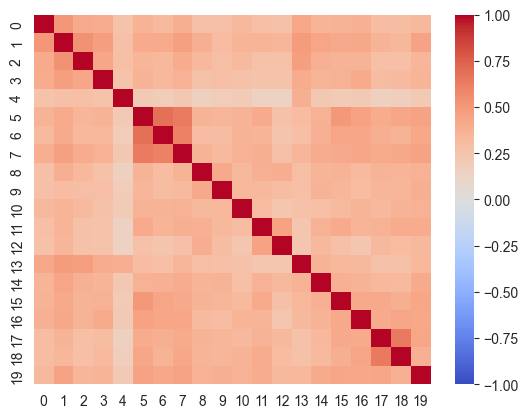

In [763]:
q = returns.quantile(0.05)
tail_dependence = np.zeros((20,20))

def tail_dep(i, j, returns):
    both = ((returns[i] < q[i]) & (returns[j] < q[j])).mean()
    single = (returns[i] < q[i]).mean()
    return both / single

for i, stock_1 in enumerate(stocks):
    for j, stock_2 in enumerate(stocks):
        tail_dependence[i,j] = tail_dep(stock_1,stock_2, returns)

sns.heatmap(tail_dependence, vmin=-1, vmax=1, cmap='coolwarm')

<Axes: >

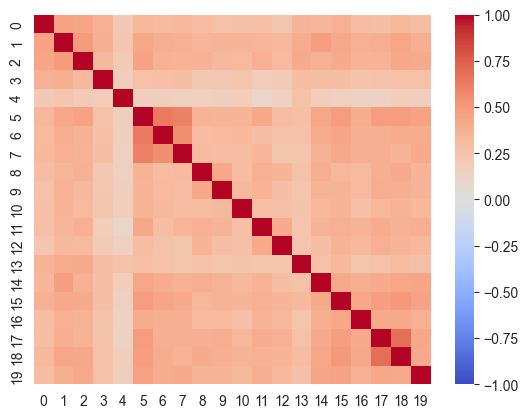

In [764]:
q = traj_df.quantile(0.05)
tail_dependence_sim = np.zeros((20,20))

for i, stock_1 in enumerate(stocks):
    for j, stock_2 in enumerate(stocks):
        tail_dependence_sim[i,j] = tail_dep(stock_1,stock_2, traj_df)

sns.heatmap(tail_dependence_sim, vmin=-1, vmax=1, cmap='coolwarm')

In [765]:
tail_dependence_sim.mean() / tail_dependence.mean()

np.float64(0.9747109147315972)

## Factor model

In [23]:
# PCA on returns

from sklearn.decomposition import PCA

pca = PCA(6)

pca.fit(returns)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",6
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [24]:
pca.explained_variance_ratio_.sum()

np.float64(0.7995951103324699)

In [25]:
factors = pca.transform(returns)

<Axes: xlabel='Date'>

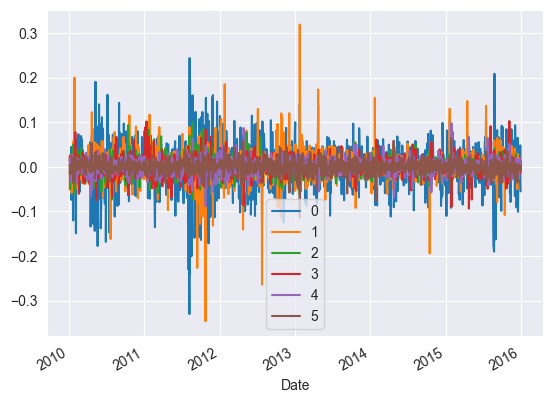

In [26]:
factors = pd.DataFrame(factors, index=returns.index)
factors.plot()

<Axes: >

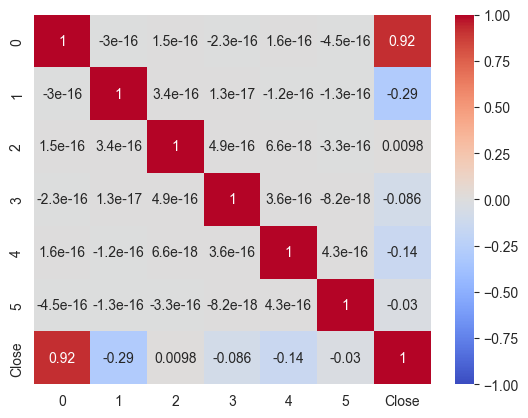

In [27]:
# The first factor is almost the market return
sns.heatmap(factors.join(r_m).corr(), vmin=-1, vmax=1, cmap='coolwarm', annot=True)

<Axes: >

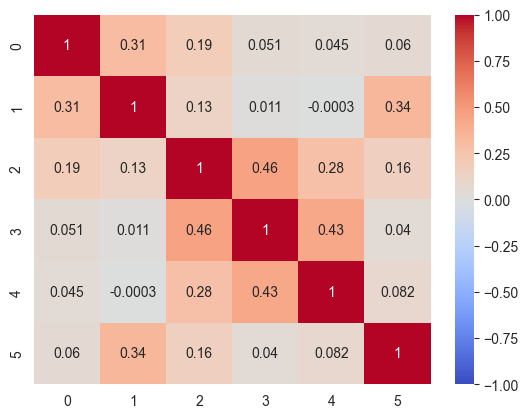

In [28]:
sns.heatmap((factors**2).corr(), vmin=-1, vmax=1, cmap='coolwarm', annot=True)

In [29]:
B = pca.components_.T
a = returns.mean()

In [30]:
r_hat = (B @ factors.T) + np.array(a)[:, None]

r_hat.index = stocks

residuals = returns.add(-r_hat.T)
std_res = residuals / residuals.std()

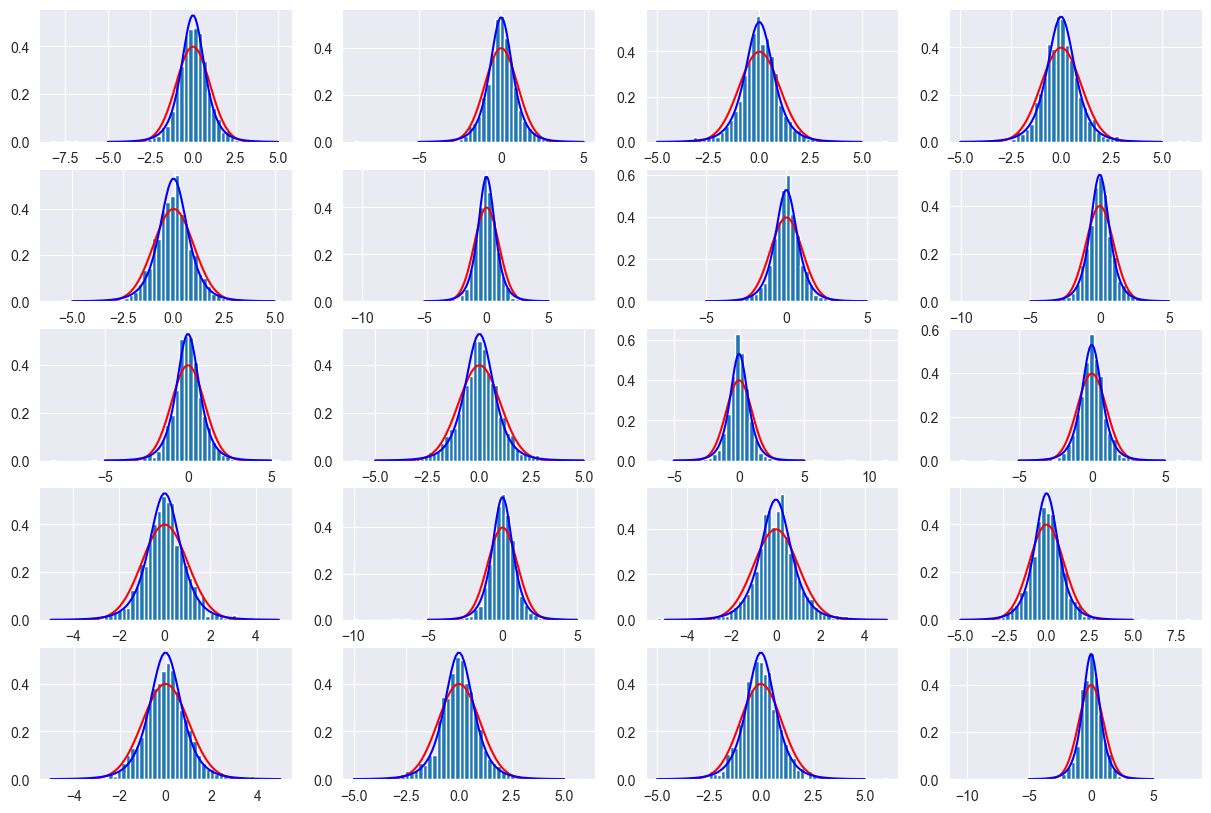

In [31]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, ax = plt.subplots(5,4, figsize=(15,10))
df = 4
scale = np.sqrt((df-2) / df) 

for i,stock in enumerate(std_res.columns):
    ax[(i%5, i%4)].hist(std_res[stock], bins=50, density=True)
    ax[(i%5, i%4)].plot(np.linspace(-5,5, 100), stats.norm.pdf(np.linspace(-5,5, 100)), label="normal", color='red')
    ax[(i%5, i%4)].plot(np.linspace(-5,5, 100), stats.t.pdf(np.linspace(-5,5, 100), scale=scale, df=df), label="t-distribution", color='blue')

<Axes: >

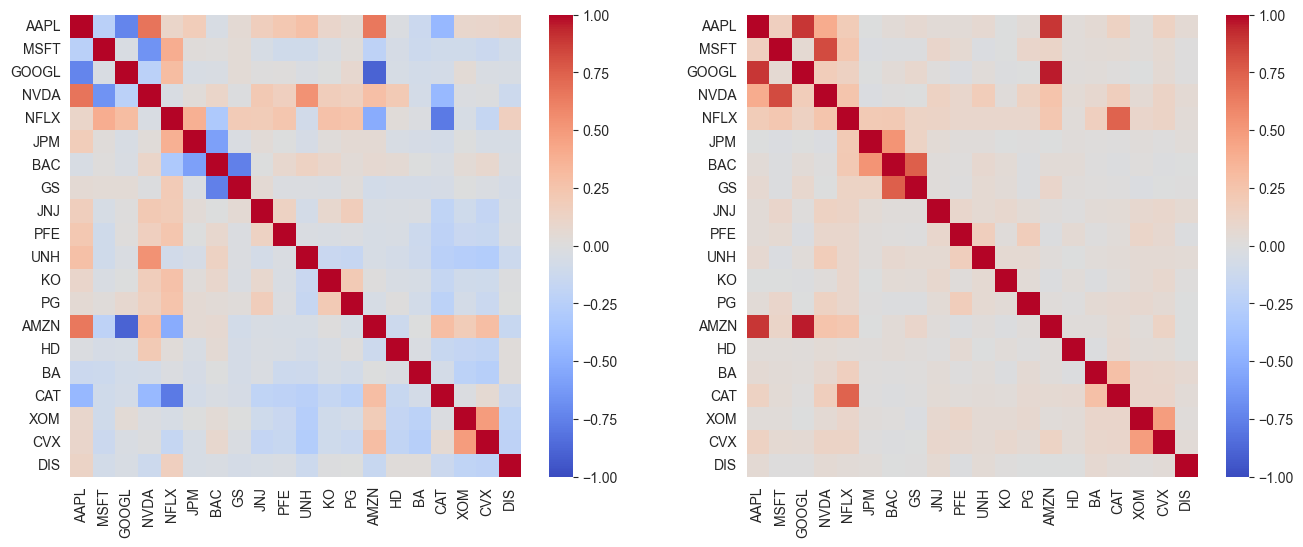

In [32]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

sns.heatmap(residuals.corr(), vmin=-1, vmax=1, cmap='coolwarm', ax=ax[0])
sns.heatmap((residuals**2).corr(), vmin=-1, vmax=1, cmap='coolwarm', ax=ax[1]) # Very similar to the actual correlation - L probably takes care of that

In [33]:
from arch import arch_model

f_models = {}
std_resids = pd.DataFrame()
vols = pd.DataFrame()

factors.columns = [f"Factor {i+1}" for i in range(factors.shape[1])]

for i in range(6):
    y = factors*100

    if i == 0:
        mm = arch_model(y[f"Factor {i+1}"], mean='zero', vol='GARCH', p=2, q=1, dist='t') # BIC had 6 points improvement (so 6 less) than GARCH(2,2)
    elif i == 4:
        mm = arch_model(y[f"Factor {i+1}"], mean='zero', vol='GARCH', p=2, q=0, dist='t')
    else:
        mm = arch_model(y[f"Factor {i+1}"], mean='zero', vol='GARCH', p=1, q=1, dist='t')
    
    f_models[i] = mm.fit(disp=False)

    std_resids[i] = f_models[i].std_resid
    vols[i] = f_models[i].conditional_volatility

In [34]:
f_models[4].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Zero Mean - ARCH Model Results                           
====================================================================================
Dep. Variable:                     Factor 5   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                             ARCH   Log-Likelihood:               -2754.73
Distribution:      Standardized Student's t   AIC:                           5517.46
Method:                  Maximum Likelihood   BIC:                           5538.74
                                              No. Observations:                 1509
Date:                      Fri, Apr 17 2026   Df Residuals:                     1509
Time:                              11:02:43   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          2.0099      0.172     11.666  1.894e-31   [  1.672,  2.348]
alpha[1]       0.1054  3.989e-02      2.641  8.260e-03 [2.718e-02,  0.184]
alpha[2]       0.1130  4.722e-02      2.393  1.669e-02 [2.047e-02,  0.206]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.0751      0.675      7.521  5.456e-14 [  3.752,  6.398]
========================================================================

Covariance estimator: robust
"""

<Axes: >

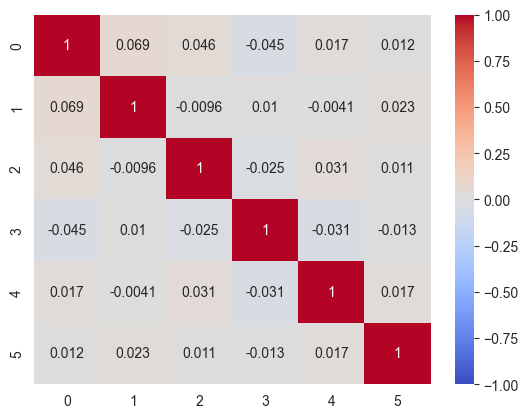

In [35]:
sns.heatmap(std_resids.corr(), vmin=-1, vmax=1, cmap="coolwarm", annot=True)

<Axes: >

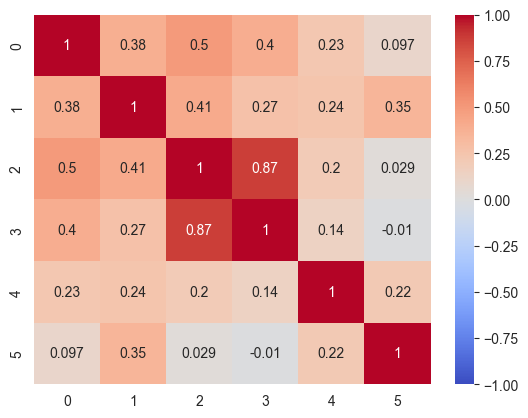

In [36]:
sns.heatmap(vols.corr(), vmin=-1, vmax=1, cmap="coolwarm", annot=True)

In [37]:
from statsmodels.stats.diagnostic import acorr_ljungbox

dd = pd.DataFrame()

# NOTE: tried VAR(1), AR(10) and they were ineffective

for i in range(6): 
    dd[i] = acorr_ljungbox(std_resids[i].dropna()**2, lags=[1, 5, 20])['lb_pvalue']

dd.T.round(3)

,1,5,20
0,0.070,0.072,0.127
1,0.725,0.909,0.999
2,0.240,0.575,0.195
3,0.552,0.147,0.045
4,0.629,0.024,0.524
5,0.924,0.433,0.495


In [38]:
for i in range(6): 
    dd[i] = acorr_ljungbox(std_resids[i].dropna(), lags=[1, 5, 20])['lb_pvalue']

dd.T.round(3) # Nothing significant with 1% confidence level

,1,5,20
0,0.387,0.100,0.474
1,0.593,0.942,0.890
2,0.217,0.017,0.051
3,0.794,0.630,0.886
4,0.575,0.107,0.519
5,0.175,0.731,0.434


In [39]:
dd = pd.DataFrame()

for stock in stocks: 
    
    dd[stock] = acorr_ljungbox(residuals[stock]**2, lags=[1, 5, 20])['lb_pvalue']
dd.T.round(3)

,1,5,20
AAPL,0.554,0.257,0.975
MSFT,0.170,0.765,1.000
GOOGL,0.611,0.009,0.397
NVDA,0.021,0.165,0.898
NFLX,0.489,0.673,0.417
JPM,0.000,0.000,0.000
BAC,0.000,0.000,0.000
GS,0.000,0.000,0.000
JNJ,0.000,0.000,0.000
PFE,0.012,0.000,0.002


## Volatility model

In [26]:
log_factors = np.log(factors**2)

In [27]:
from statsmodels.tsa.api import VAR

log_model = VAR(log_factors).fit(maxlags=4, trend='c')
log_res = log_model.resid

log_model.is_stable()

c:\Users\lovas\Desktop\Szakdoga\code\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


np.True_

In [28]:
acorr_ljungbox(log_res[f'Factor {1}'].dropna(), lags=[1, 5, 20])['lb_pvalue'].round(3)

1     0.697
5     0.898
20    0.152
Name: lb_pvalue, dtype: float64

In [64]:
def simulate_factor(log_model, h_init, T=1000):
    coefs = log_model.coefs        # shape: (p, k, k)
    intercept = log_model.intercept
    log_res = log_model.resid

    p = log_model.k_ar

    #e_t = bootstrap_samples(log_res, n_bootstrap=1, sample_size=T)
    e_t = stationary_bootstrap(log_res, n_bootstrap=1, sample_size=T, avg_block_size=20)

    k = log_factors.shape[1]
    h_sim = np.zeros((T + p, k))

    # set initial values
    h_sim[:p] = h_init

    for t in range(p, T + p):
        h_t = intercept.copy()
        
        for i in range(p):
            h_t += coefs[i] @ h_sim[t - i - 1]
        
        h_t += e_t[0][t - p]
        
        h_sim[t] = h_t

    # drop initial values
    h_sim = h_sim[p:]

    #z_t = np.random.standard_t(df=4, size=h_sim.shape) * np.sqrt((4-2) / 4)
    z_t = stationary_bootstrap(std_resids, 1, T, 20)[0]

    f_t = np.exp(h_sim / 2) * z_t

    f_t = f_t.clip(-0.4, 0.4)

    return f_t

In [65]:
def simulate_trajectory_v2(log_model, h_init, T, B, a, Sigma):
    f_t = simulate_factor(log_model, h_init, T).T

    #L = np.linalg.cholesky(Sigma)
    #eps = np.random.rand(nobs, B.shape[0]) @ L
    #eps = stats.t.rvs(scale=scale, df=df, size=(T, B.shape[0])) @ L.T
    #eps = bootstrap_samples(residuals, n_bootstrap=1, sample_size=T)[0]
    eps = stationary_bootstrap(residuals, n_bootstrap=1, sample_size=T, avg_block_size=20)[0]

    r = a.values[None, :] + (B @ f_t).T + eps

    return r

In [66]:
sigma = residuals.cov()  + np.eye(residuals.shape[1]) * 1e-8

sim = simulate_trajectory_v2(
    log_model, log_factors.values[-4:], 1509, B, a, sigma
)
sim_traj = pd.DataFrame(sim, columns=stocks)

## Simulation

In [22]:
garch_stocks = ((dd.T) < 0.01).any(axis=1)

In [25]:
stock_garch_models = {}

for stock in stocks:
    if garch_stocks.loc[stock]:
        stock_garch_models[stock] = arch_model(y=residuals[stock]*10, mean='zero', vol='GARCH', p=1, q=1, dist='t').fit(disp=False)
        residuals[stock] = stock_garch_models[stock].std_resid

In [ ]:
df = 4
scale = np.sqrt((df-2) / df) 

def simulate_trajectories(f_models, nobs, a, B, Sigma):
    N_factors = len(f_models)

    f = np.zeros((N_factors, nobs))

    for i, model in f_models.items():
        f_sim = model.model.simulate(params=model.params, nobs=nobs)
        
        f[i] = f_sim['data'] / 100

    L = np.linalg.cholesky(Sigma)
    #eps = np.random.rand(nobs, B.shape[0]) @ L
    eps = stats.t.rvs(scale=scale, df=df, size=(nobs, B.shape[0])) @ L.T

    r = a + (B @ f).T + eps

    return r

In [228]:
sigma = residuals.cov()  + np.eye(residuals.shape[1]) * 1e-8
sim_traj = simulate_trajectories(f_models, 1509, np.array(a), B, sigma)

In [287]:
sim_traj = pd.DataFrame(sim_traj, columns=stocks)

<Axes: >

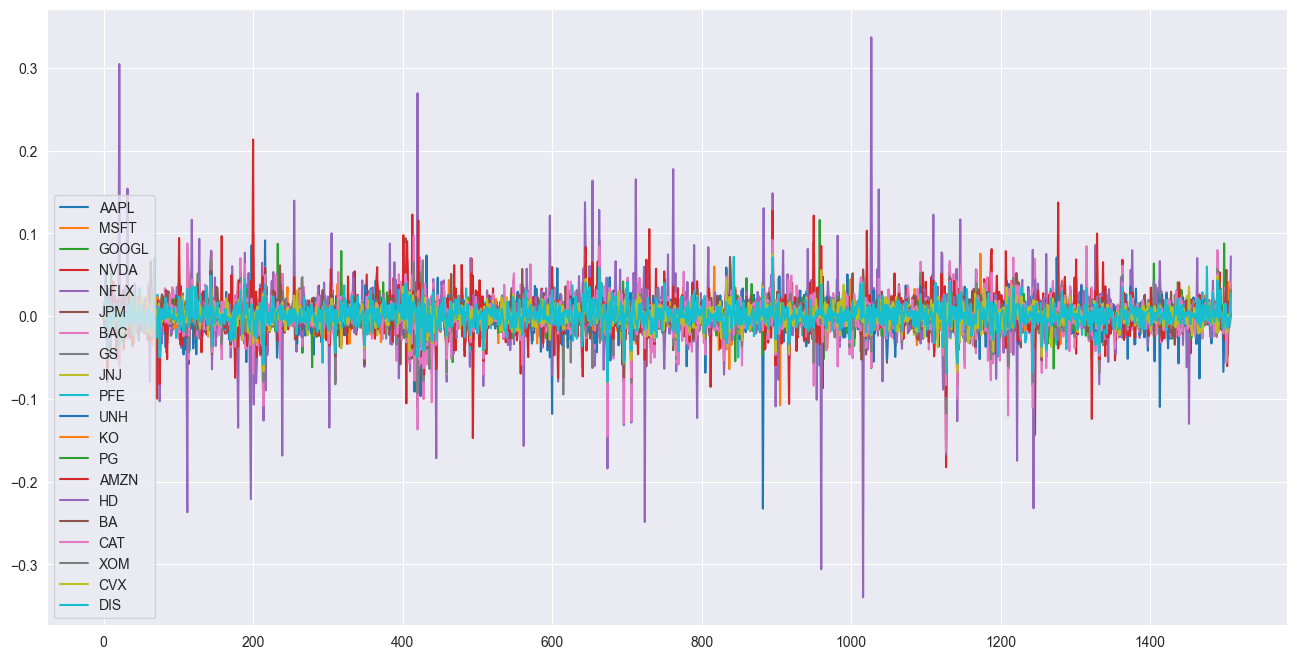

In [67]:
sim_traj.plot(figsize=(16,8))

<Axes: xlabel='Date'>

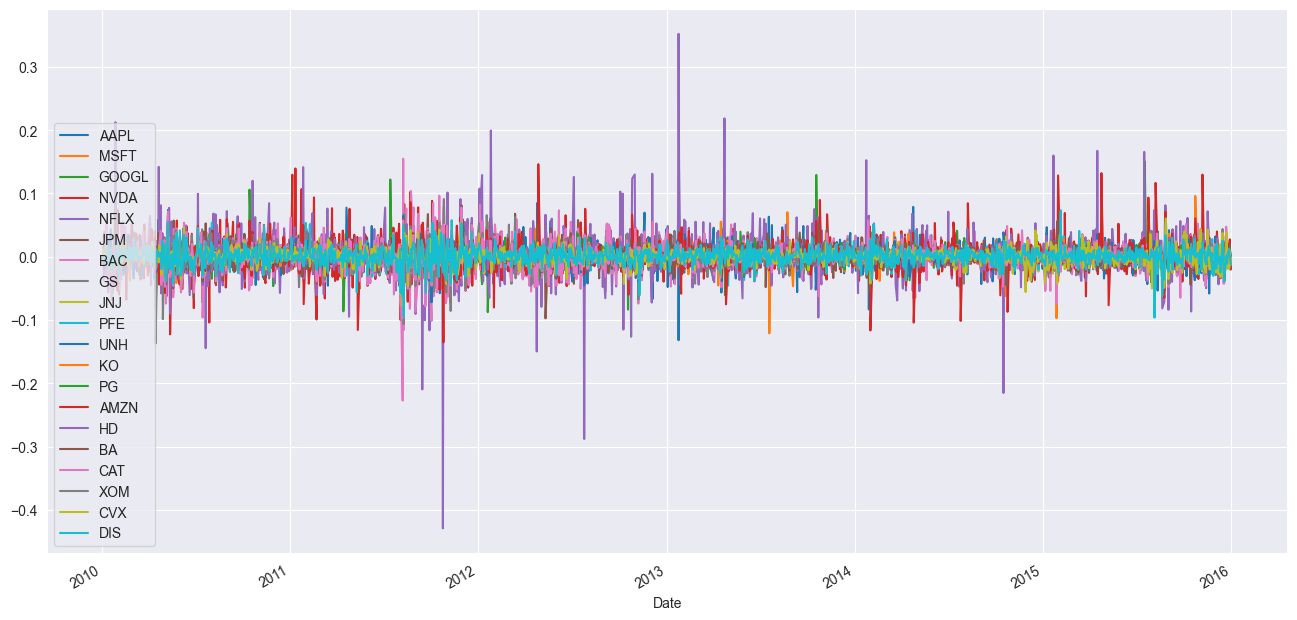

In [332]:
returns.plot(figsize=(16,8))

In [360]:
returns.describe()

,AAPL,MSFT,GOOGL,NVDA,NFLX,JPM,BAC,GS,JNJ,PFE,UNH,KO,PG,AMZN,HD,BA,CAT,XOM,CVX,DIS
count,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000
mean,0.000867,0.000492,0.000602,0.000424,0.001793,0.000376,0.000070,0.000078,0.000435,0.000500,0.000931,0.000389,0.000299,0.001073,0.001108,0.000720,0.000201,0.000188,0.000226,0.000839
std,0.016808,0.014632,0.015991,0.023581,0.037095,0.017399,0.022975,0.017257,0.008885,0.011832,0.015178,0.009601,0.009016,0.020590,0.012977,0.015103,0.017177,0.011882,0.013513,0.014016
min,-0.131885,-0.121033,-0.087493,-0.122572,-0.429178,-0.098880,-0.227129,-0.136863,-0.032683,-0.048618,-0.083029,-0.062185,-0.060600,-0.135325,-0.060686,-0.075625,-0.096740,-0.063879,-0.078396,-0.096190
25%,-0.007753,-0.007488,-0.007458,-0.011841,-0.014398,-0.008361,-0.011063,-0.008729,-0.004066,-0.005973,-0.007540,-0.004703,-0.004296,-0.009321,-0.005469,-0.007549,-0.008184,-0.005973,-0.006907,-0.006114
50%,0.000885,0.000219,0.000384,0.000470,0.000280,0.000503,0.000000,0.000694,0.000305,0.000000,0.001058,0.000472,0.000254,0.000557,0.000927,0.000814,0.000155,-0.000131,0.000477,0.001080
75%,0.010699,0.008293,0.008512,0.011976,0.017055,0.009625,0.011335,0.009141,0.005408,0.007054,0.009631,0.005742,0.005155,0.012594,0.007897,0.009100,0.009324,0.006899,0.007692,0.008253
max,0.085022,0.099413,0.150645,0.139484,0.352230,0.081012,0.154808,0.090486,0.052422,0.054888,0.077605,0.055313,0.039612,0.146225,0.055384,0.070574,0.077950,0.053691,0.060391,0.073531


In [68]:
sim_traj.describe()

,AAPL,MSFT,GOOGL,NVDA,NFLX,JPM,BAC,GS,JNJ,PFE,UNH,KO,PG,AMZN,HD,BA,CAT,XOM,CVX,DIS
count,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000
mean,-0.000181,0.000331,0.000361,0.000791,0.001004,-0.000366,-0.000896,-0.000606,0.000394,0.000609,0.000951,0.000204,0.000581,0.000999,0.001161,0.000748,-0.000479,0.000206,0.000270,0.000978
std,0.017989,0.014171,0.017089,0.023199,0.037956,0.017621,0.023789,0.017538,0.009064,0.011634,0.015287,0.009376,0.008829,0.021878,0.012952,0.015295,0.017050,0.012030,0.013416,0.014053
min,-0.232645,-0.107632,-0.083086,-0.182675,-0.339826,-0.118907,-0.163918,-0.117419,-0.045961,-0.050211,-0.067473,-0.041593,-0.054583,-0.147351,-0.066163,-0.085435,-0.105358,-0.079397,-0.080721,-0.079848
25%,-0.006597,-0.006832,-0.007299,-0.008000,-0.008057,-0.007123,-0.009326,-0.007786,-0.004319,-0.005727,-0.006324,-0.004740,-0.004238,-0.007840,-0.005850,-0.007023,-0.008759,-0.005622,-0.006413,-0.006242
50%,0.000624,0.000730,0.000764,0.000671,0.001843,0.000324,-0.000042,0.000242,0.000342,0.000733,0.001825,0.000516,0.000695,0.001330,0.001143,0.000532,0.000111,0.000731,0.000714,0.001001
75%,0.007622,0.007643,0.008320,0.009955,0.011498,0.007264,0.009441,0.008290,0.005558,0.007097,0.009495,0.005310,0.005779,0.010520,0.008269,0.008442,0.008738,0.006403,0.007411,0.008185
max,0.093269,0.078176,0.116213,0.137252,0.337026,0.094107,0.097698,0.079977,0.051140,0.061522,0.070783,0.038195,0.038891,0.213476,0.067257,0.086303,0.092085,0.065111,0.075137,0.071782


<Axes: >

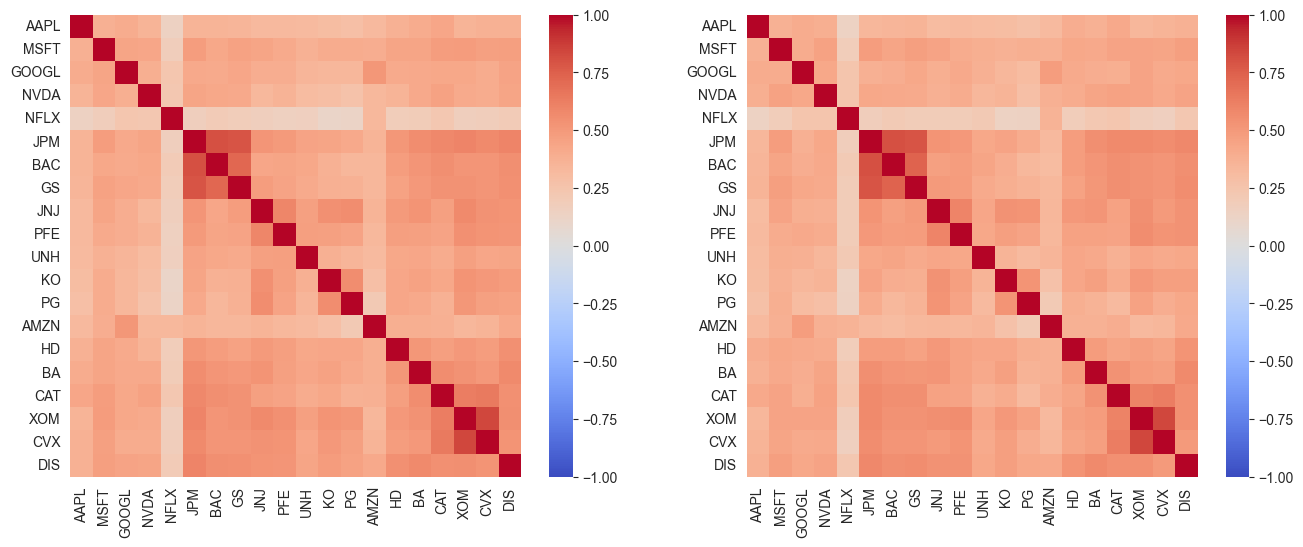

In [155]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

sns.heatmap(returns.corr(), vmin=-1, vmax=1, cmap='coolwarm', ax=ax[0])
sns.heatmap(sim_traj.corr(), vmin=-1, vmax=1, cmap='coolwarm', ax=ax[1])

<Axes: >

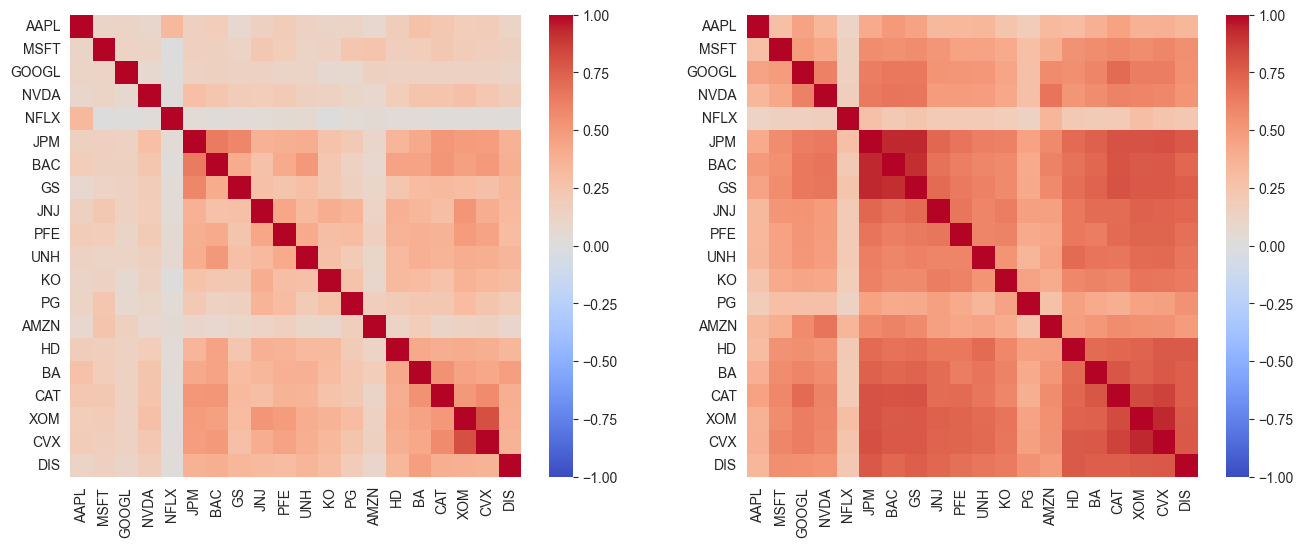

In [156]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

sns.heatmap((returns**2).corr(), vmin=-1, vmax=1, cmap='coolwarm', ax=ax[0])
sns.heatmap((sim_traj**2).corr(), vmin=-1, vmax=1, cmap='coolwarm', ax=ax[1])